# Notebook 03 — Sales Dashboard Final
**Dataset:** Brazilian E-Commerce (Olist)  
**Output:** `output/dashboard.png` — layout satu halaman siap presentasi ke client.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from pathlib import Path

OUT     = Path('../output')
FIGURES = OUT / 'figures'

BLUE      = '#2563EB'
LIGHT     = '#93C5FD'
LIGHTER   = '#DBEAFE'
RED       = '#DC2626'
GRAY      = '#6B7280'
BG        = '#F8FAFC'
CARD_BG   = '#FFFFFF'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': BG,
    'axes.facecolor': CARD_BG,
})

df = pd.read_parquet(OUT / 'df_master.parquet')
df['order_month']   = df['order_month'].astype('period[M]')
print(f'Loaded {len(df):,} rows')

Loaded 110,197 rows


In [2]:
# ── Pre-compute semua data yang dibutuhkan ──────────────────────────────────

# KPI
total_revenue = df['revenue'].sum()
total_orders  = df['order_id'].nunique()
aov_overall   = df.groupby('order_id')['revenue'].sum().mean()
avg_score     = df.drop_duplicates('order_id')['review_score'].mean()

# Monthly trend
monthly = (
    df.groupby('order_month')
    .agg(revenue=('revenue', 'sum'), orders=('order_id', 'nunique'))
    .reset_index()
)
monthly = monthly.iloc[1:-1].reset_index(drop=True)
monthly['month_str'] = monthly['order_month'].astype(str)

# Top 10 category by revenue
cat_rev = (
    df.groupby('category')['revenue'].sum()
    .nlargest(10).reset_index()
    .sort_values('revenue')
)

# Revenue by state (top 12)
state_rev = (
    df.groupby('customer_state')['revenue'].sum()
    .nlargest(12).reset_index()
    .sort_values('revenue')
)

# Payment type
pay_dist = df.drop_duplicates('order_id')['payment_type'].value_counts()

# Review score
score_dist = df.drop_duplicates('order_id')['review_score'].value_counts().sort_index()

print('Data ready.')

Data ready.


Saved: output/dashboard.png


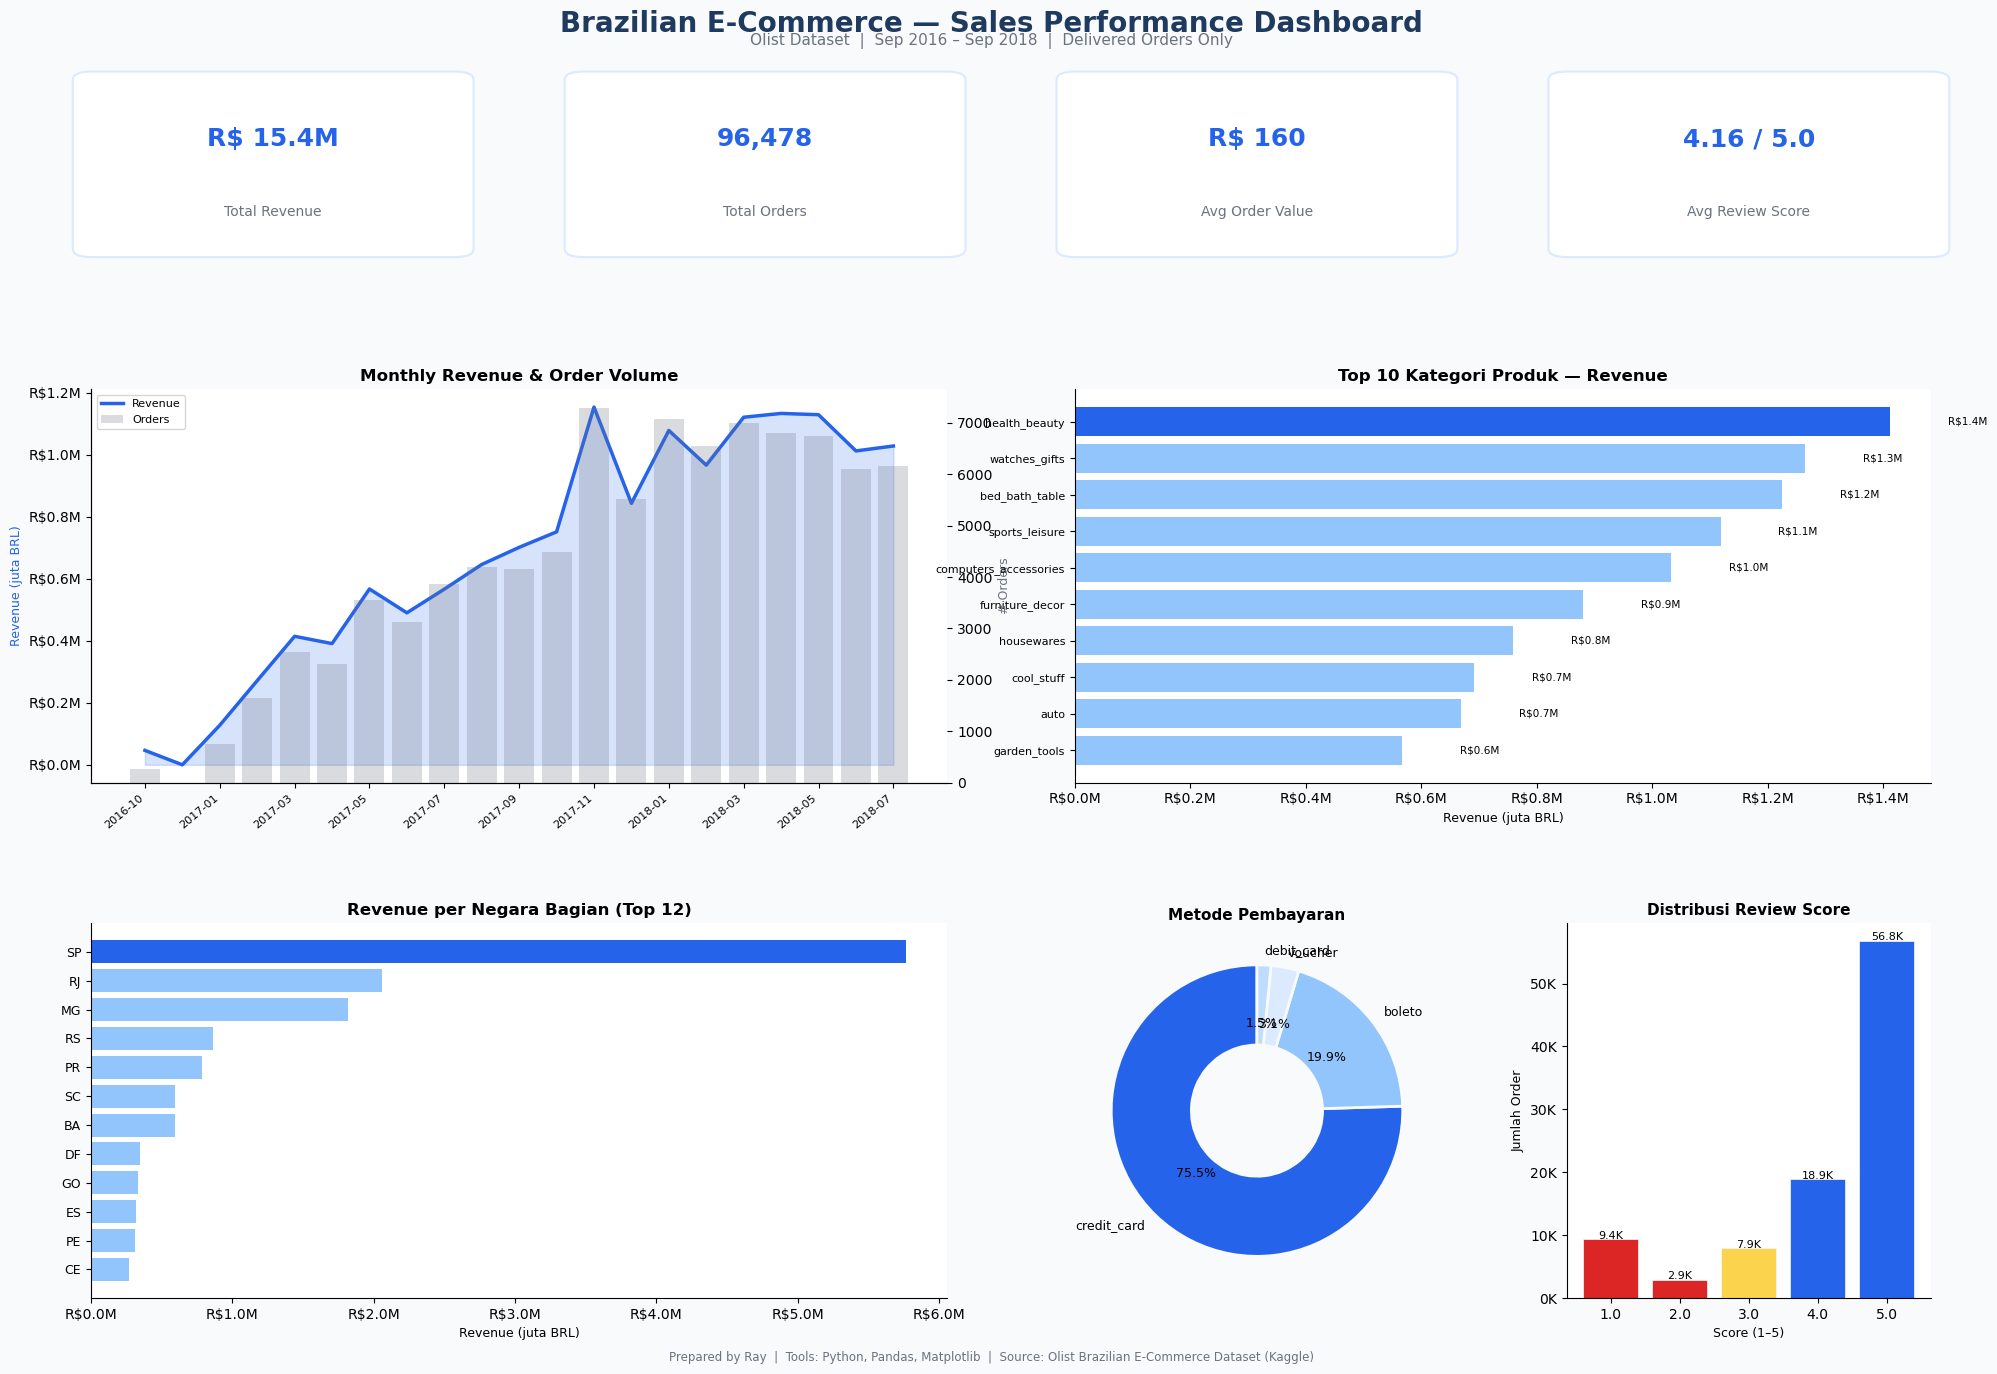

In [3]:
# ── Build Dashboard Layout ──────────────────────────────────────────────────

fig = plt.figure(figsize=(20, 14), facecolor=BG)
fig.suptitle(
    'Brazilian E-Commerce — Sales Performance Dashboard',
    fontsize=20, fontweight='bold', y=0.98, color='#1E3A5F'
)
fig.text(0.5, 0.955, 'Olist Dataset  |  Sep 2016 – Sep 2018  |  Delivered Orders Only',
         ha='center', fontsize=11, color=GRAY)

gs = gridspec.GridSpec(
    3, 4,
    figure=fig,
    height_ratios=[0.18, 0.42, 0.40],
    hspace=0.45,
    wspace=0.35,
    top=0.93, bottom=0.06, left=0.05, right=0.97
)

# ── ROW 0: KPI Cards ───────────────────────────────────────────────────────
kpis = [
    ('Total Revenue', f'R$ {total_revenue/1e6:.1f}M', BLUE),
    ('Total Orders',  f'{total_orders:,}',             BLUE),
    ('Avg Order Value', f'R$ {aov_overall:,.0f}',      BLUE),
    ('Avg Review Score', f'{avg_score:.2f} / 5.0',     BLUE),
]

for col, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, col])
    ax.set_facecolor(CARD_BG)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(False)
    rect = mpatches.FancyBboxPatch(
        (0, 0), 1, 1,
        boxstyle='round,pad=0.05',
        facecolor=CARD_BG,
        edgecolor=LIGHTER,
        linewidth=1.5,
        transform=ax.transAxes,
        clip_on=False
    )
    ax.add_patch(rect)
    ax.text(0.5, 0.65, value, ha='center', va='center',
            fontsize=18, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.22, label, ha='center', va='center',
            fontsize=10, color=GRAY, transform=ax.transAxes)

# ── ROW 1, col 0-1: Revenue Trend ─────────────────────────────────────────
ax_trend = fig.add_subplot(gs[1, :2])
ax_orders = ax_trend.twinx()

ax_trend.fill_between(range(len(monthly)), monthly['revenue'] / 1e6,
                      alpha=0.18, color=BLUE)
ax_trend.plot(range(len(monthly)), monthly['revenue'] / 1e6,
              color=BLUE, linewidth=2.5, label='Revenue')
ax_orders.bar(range(len(monthly)), monthly['orders'],
              alpha=0.25, color=GRAY, label='Orders')

tick_step = max(1, len(monthly) // 10)
ax_trend.set_xticks(range(0, len(monthly), tick_step))
ax_trend.set_xticklabels(
    monthly['month_str'].iloc[::tick_step], rotation=40, ha='right', fontsize=8
)
ax_trend.set_ylabel('Revenue (juta BRL)', color=BLUE, fontsize=9)
ax_orders.set_ylabel('# Orders', color=GRAY, fontsize=9)
ax_trend.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.1f}M'))
ax_trend.set_title('Monthly Revenue & Order Volume', fontweight='bold', fontsize=12)
lines1, labs1 = ax_trend.get_legend_handles_labels()
lines2, labs2 = ax_orders.get_legend_handles_labels()
ax_trend.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper left')

# ── ROW 1, col 2-3: Top 10 Category ───────────────────────────────────────
ax_cat = fig.add_subplot(gs[1, 2:])
bar_colors_cat = [BLUE if i == len(cat_rev) - 1 else LIGHT for i in range(len(cat_rev))]
ax_cat.barh(cat_rev['category'], cat_rev['revenue'] / 1e6, color=bar_colors_cat)
ax_cat.set_xlabel('Revenue (juta BRL)', fontsize=9)
ax_cat.set_title('Top 10 Kategori Produk — Revenue', fontweight='bold', fontsize=12)
ax_cat.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.1f}M'))
ax_cat.tick_params(axis='y', labelsize=8)
for i, v in enumerate(cat_rev['revenue'] / 1e6):
    ax_cat.text(v + 0.1, i, f'R${v:.1f}M', va='center', fontsize=7.5)

# ── ROW 2, col 0-1: Revenue by State ──────────────────────────────────────
ax_state = fig.add_subplot(gs[2, :2])
bar_colors_state = [BLUE if i == len(state_rev) - 1 else LIGHT for i in range(len(state_rev))]
ax_state.barh(state_rev['customer_state'], state_rev['revenue'] / 1e6,
              color=bar_colors_state)
ax_state.set_xlabel('Revenue (juta BRL)', fontsize=9)
ax_state.set_title('Revenue per Negara Bagian (Top 12)', fontweight='bold', fontsize=12)
ax_state.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.1f}M'))
ax_state.tick_params(axis='y', labelsize=9)

# ── ROW 2, col 2: Payment Mix ─────────────────────────────────────────────
ax_pay = fig.add_subplot(gs[2, 2])
wedge_colors = [BLUE, LIGHT, LIGHTER, '#BFDBFE']
ax_pay.pie(
    pay_dist.values, labels=pay_dist.index,
    autopct='%1.1f%%', colors=wedge_colors,
    wedgeprops={'width': 0.55, 'edgecolor': BG, 'linewidth': 2},
    startangle=90, textprops={'fontsize': 9}
)
ax_pay.set_title('Metode Pembayaran', fontweight='bold', fontsize=11)

# ── ROW 2, col 3: Review Score ────────────────────────────────────────────
ax_score = fig.add_subplot(gs[2, 3])
bar_colors_score = [RED if s <= 2 else ('#FCD34D' if s == 3 else BLUE)
                    for s in score_dist.index]
ax_score.bar(score_dist.index.astype(str), score_dist.values, color=bar_colors_score,
             edgecolor=BG, linewidth=0.5)
ax_score.set_xlabel('Score (1–5)', fontsize=9)
ax_score.set_ylabel('Jumlah Order', fontsize=9)
ax_score.set_title('Distribusi Review Score', fontweight='bold', fontsize=11)
ax_score.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
for i, v in enumerate(score_dist.values):
    ax_score.text(i, v + 100, f'{v/1000:.1f}K', ha='center', fontsize=8)

# ── Footer ─────────────────────────────────────────────────────────────────
fig.text(
    0.5, 0.015,
    'Prepared by Ray  |  Tools: Python, Pandas, Matplotlib  |  Source: Olist Brazilian E-Commerce Dataset (Kaggle)',
    ha='center', fontsize=8.5, color=GRAY
)

# ── Export ─────────────────────────────────────────────────────────────────
plt.savefig(OUT / 'dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG)
print('Saved: output/dashboard.png')
plt.show()

## Executive Summary

### Temuan Utama
| Dimensi | Insight |
|---|---|
| **Revenue Trend** | Tumbuh konsisten Sep 2016–Agu 2018; puncak Q4 (Nov–Des) mengindikasikan seasonal pattern kuat |
| **Konsentrasi Geografis** | São Paulo + Rio de Janeiro mendominasi revenue — risiko konsentrasi tinggi; ekspansi ke negara bagian lain berpotensi besar |
| **Top Kategori** | *bed_bath_table*, *health_beauty*, *sports_leisure* — tiga kategori ini kontribusi >30% total revenue |
| **Payment Mix** | Credit card >70% transaksi; boleto masih signifikan sebagai alternatif segmen unbanked |
| **Kepuasan Pelanggan** | Avg review score >4.0/5.0; distribusi J-curve menandakan silent majority puas |

### Business Recommendation
1. **Geografis:** Alokasikan budget akuisisi ke Minas Gerais + Rio Grande do Sul — potensi tinggi, kompetisi lebih rendah dari SP.
2. **Seasonal:** Persiapkan inventory 6–8 minggu sebelum November untuk mengantisipasi demand spike Q4.
3. **Kategori:** Investasikan lebih dalam pada *health_beauty* — growth rate tertinggi dan margin premium.

> **Relevansi Indonesia:** Pola ini cermin kondisi Tokopedia/Shopee — DKI Jakarta + Jabar menyumbang ~45-50% GMV nasional, sama seperti SP+RJ di Brasil. Harbolnas 11.11/12.12 analog dengan peak Q4 dataset ini.
